# Train RBM on esmif generated sequences

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
BEGIN=18
END=5


In [2]:
import os, sys
pgm_path = '../PGM/'
if not os.path.isdir(pgm_path): # check if folder exists
    from git import Repo
    Repo.clone_from("https://github.com/jertubiana/PGM.git", pgm_path)
sys.path.append(pgm_path + 'source/')
sys.path.append(pgm_path + 'utilities/')
# sys.path.append('DNA_utils/')

In [3]:
# imports

import rbm, RBM_utils

import random
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import utilities, Proteins_utils, sequence_logo, plots_utils 



e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


## RBM artificial sequence generation


In [4]:
from global_variables import *
artificial_seq,artificial_sequences_representation = RBM.gen_data(Nthermalize=1000,Nchains=100,Lchains=10,Nstep=100) # Generate artificial samples by Markov Chain Monte Carlo.


Loaded 29 KD vectors


In [5]:
artificial_seqs=[Proteins_utils.num2seq(s) for s in artificial_seq]
artificial_seqs


['...']

In [6]:
import textwrap

sequences =artificial_seqs

output_filename = 'RBM_artif_seq.fasta'
line_width = 60  # Standard width for FASTA lines

try:
    with open(output_filename, 'w') as f:
        for i, seq in enumerate(sequences, start=1):
            
            header = f">seq_{i}\n"
            f.write(header)
            
            wrapped_seq = textwrap.fill(seq, width=line_width)
            f.write(wrapped_seq + "\n")

    print(f"Successfully saved sequences to {output_filename}")

except IOError as e:
    print(f"Error writing to file: {e}")

Successfully saved sequences to RBM_artif_seq.fasta


# Fasta processing

In [7]:
WT='SVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCG'
len(WT)

178

# MSA reading for RBM training

In [8]:
wt_omicron=Proteins_utils.load_FASTA('exp_data/wt_omicron.fasta')
print('wt:', wt_omicron[0,BEGIN:-END])



wt: [15 17 19  0 18 11 14  8 14  7 15 11  1 17  0  2 19 15 17  9 19 11 15  0
 15  4 15 16  4  8  1 19  5 17 15 12 16  8  9 11  2  9  1  4 16 11 17 19
  0  2 15  4 17  7 14  5  2  3 17 14 13  7  0 12  5 13 16  5  8  7  0  2
 19 11 19  8  9 12  2  2  4 16  5  1 17  7  0 18 11 15 11 11  9  2 15  8
 17  5  5 11 19 11 19  9 19 14  9  4 14  8 15 11  9  8 12  4  3 14  2  7
 15 16  3  7 19 13  0  5 15 16 12  1 11  5 17  3  5  4 11  1 19  4 12  9
 13 15 19  5  4 13 12 16 11  5 17  5 19 13 12 19 14 17 17 17  9 15  4  3
  9  9  6  0 12  0 16 17  1  5]


In [9]:
import numpy as np

def hamming_distance(arr1, arr2):
    """
    Compute the Hamming distance between two equal-length arrays.
    """
    if len(arr1) != len(arr2):
        raise ValueError("Arrays must be of the same length")

    return np.sum(np.array(arr1) != np.array(arr2))

# Example usage
arr1 = [1, 0, 1, 1, 0, 1]
arr2 = [1, 1, 0, 1, 0, 0]

distance = hamming_distance(arr1, arr2)
print("Hamming Distance:", distance)


Hamming Distance: 3


(1000, 178)


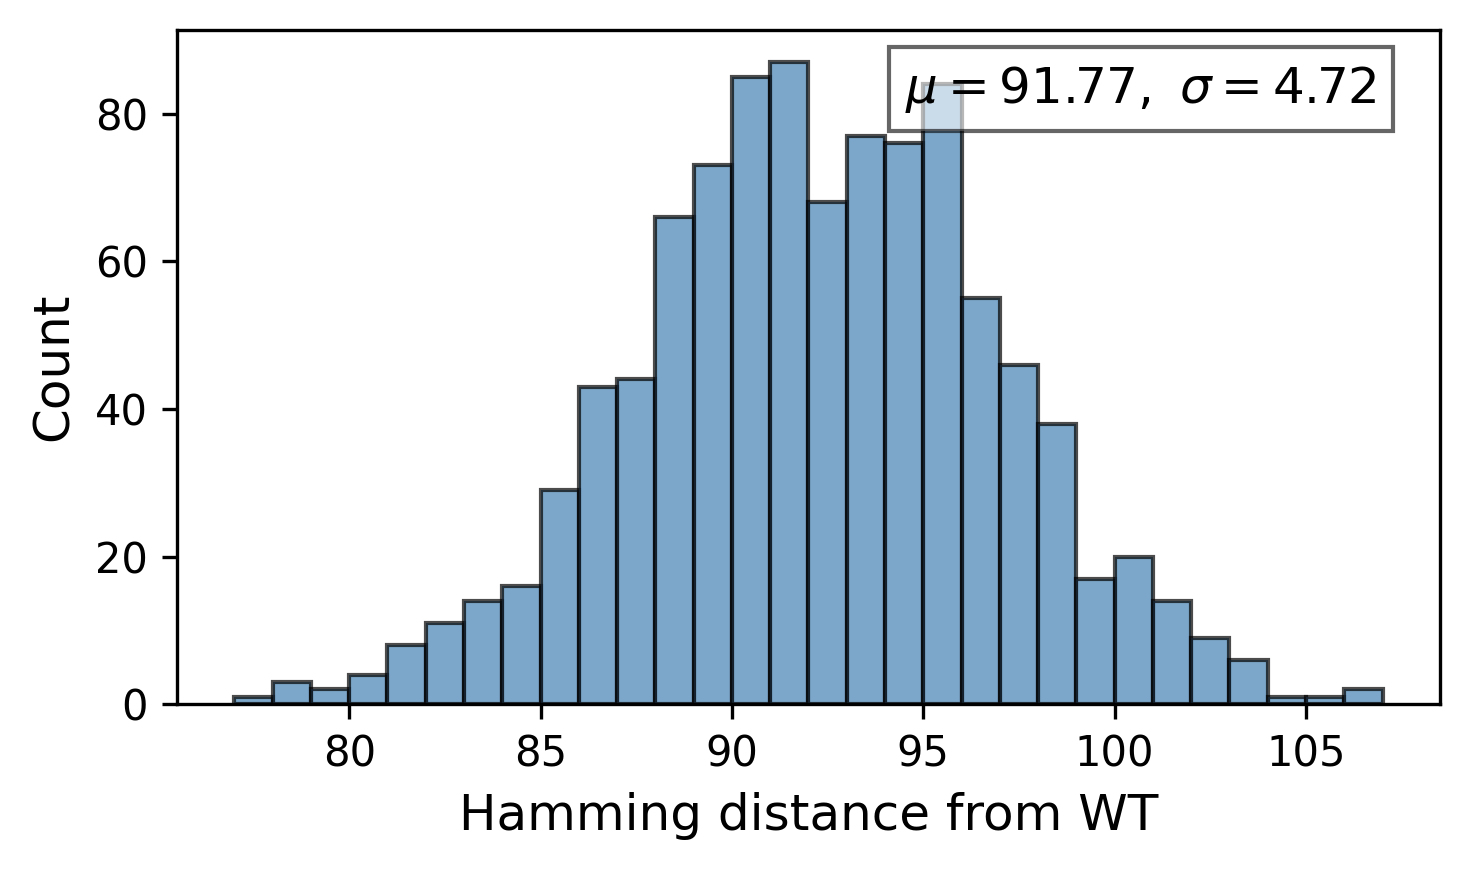

In [10]:
import matplotlib.pyplot as plt
import numpy as np

path = 'esmif_seq/'
temps = [1]

for temp in temps:
    filename = f'sampled_sequences_temp_{temp}.fasta'
    
    # Load protein sequences
    sequences = Proteins_utils.load_FASTA(path + filename)
    print(sequences.shape)
    
    hammings = [hamming_distance(wt_omicron[0, BEGIN:-END], seq) for seq in sequences]
    
    # Compute mean and std for annotation
    mean_hamming = np.mean(hammings)
    std_hamming = np.std(hammings)
    
    # Plot histogram
    plt.figure(figsize=(5,3), dpi=300)
    plt.hist(hammings, bins=30, color="steelblue", edgecolor="black", alpha=0.7)
    
    # plt.title(f"Hamming distance with WT", fontsize=14, pad=15)
    plt.xlabel("Hamming distance from WT", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    
    # Add equation (mean ± std)
    plt.text(0.95, 0.95, 
             rf"$\mu = {mean_hamming:.2f},\ \sigma = {std_hamming:.2f}$", 
             transform=plt.gca().transAxes,
             fontsize=12,
             ha="right", va="top",
             bbox=dict(facecolor="white", edgecolor="black", alpha=0.6))
    
    plt.tight_layout()
    plt.show()


## RBM training

In [11]:
path = 'esmif_seq/'


for n_h in [50]:
    for l1_b in [0.2]:
        for temp in [1]:
            filename = f'sampled_sequences_temp_{temp}.fasta'
            
            # Load protein sequences
            sequences = Proteins_utils.load_FASTA(path + filename)
            sequences = np.array(sequences)
            # Find coordinates where values are greater than 20
            mistake_coords = np.argwhere(sequences > 20)
            # Replace mistakes with WT_SEQ values based on column index
            for row, col in mistake_coords:
                sequences[row, col] = wt_omicron[0,BEGIN:-END][col]

            sequences=np.vstack([wt_omicron[0,BEGIN:-END], sequences])

            # Print shape and sequences
            print(f'Temperature: {temp}')
            print('Shape of sequences:', np.shape(sequences))
            print('Sequences:', sequences)
            
            # Training data
            train_sequences = sequences
            sequence_weights = np.ones(train_sequences.shape[0])
            # Initialize RBM
            RBM = rbm.RBM(
                visible='Potts',  # Categorical visible data.
                hidden='dReLU',  # Double ReLU hidden units.
                n_v=sequences.shape[-1],  # Data dimension (number of columns in MSA)
                n_cv=20,  # Number of categories (20 amino acids + 1 gap)
                n_h=n_h  # Number of hidden units
            )
            
            # Train RBM
            RBM.fit(train_sequences, weights=sequence_weights, n_iter=100, N_MC=10, verbose=1, vverbose=1, l1b=l1_b)
            
            # Save RBM model
            model_filename = f'ESMIF_RBM_wt_Covid_temp_{temp}_nH_{n_h}_l1B_{l1_b}.data'
            # RBM_utils.saveRBM('rbms/'+model_filename, RBM)
            
            # Compute and print likelihood
            likelihood = RBM.likelihood(train_sequences).mean()
            print(f'Likelihood for temp {temp}: {likelihood}\n')

Temperature: 1
Shape of sequences: (1001, 178)
Sequences: [[15 17 19 ... 17  1  5]
 [15 17 19 ... 17 17  5]
 [15 17 19 ... 17 16  4]
 ...
 [15 17 19 ... 17  4  5]
 [15 17 19 ... 17  8  5]
 [15 17  6 ... 17 16  5]]
Iteration number 0, pseudo-likelihood: -1.30
Starting epoch 1
[RBM] Iteration 1, time = 12.37s, pseudo-likelihood = -1.24
Starting epoch 2
[RBM] Iteration 2, time = 0.51s, pseudo-likelihood = -1.30
Starting epoch 3
[RBM] Iteration 3, time = 0.46s, pseudo-likelihood = -1.27
Starting epoch 4
[RBM] Iteration 4, time = 0.44s, pseudo-likelihood = -1.23
Starting epoch 5
[RBM] Iteration 5, time = 0.53s, pseudo-likelihood = -1.31
Starting epoch 6
[RBM] Iteration 6, time = 0.50s, pseudo-likelihood = -1.27
Starting epoch 7
[RBM] Iteration 7, time = 0.45s, pseudo-likelihood = -1.23
Starting epoch 8
[RBM] Iteration 8, time = 0.45s, pseudo-likelihood = -1.21
Starting epoch 9
[RBM] Iteration 9, time = 0.46s, pseudo-likelihood = -1.15
Starting epoch 10
[RBM] Iteration 10, time = 0.45s, pseu